In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.spines 
import random
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

pathroot="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
pathroot="D:/DATA/Projets/M1_NEURO_APP_NC"


pathdecod_Final=pathroot+"/data/UNITS_APP_FUNNELING"
pathscripts=pathroot+"/scripts/"

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

CM_MLP_allsplit_P_cluster=[]
AccScore_MLP_allsplit_cluster=[]
AccScore_MLP_allsplit_cluster_mean=[]

listfile=os.listdir(pathdecod_Final)

Neuronpop = []
for fileid in listfile:
    DFsaved=np.load(os.path.join(pathdecod_Final, fileid), allow_pickle=True)
    DF=DFsaved['arr_0']
    Neuronpop.append(DF)
    
len(Neuronpop)


76

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print(len(Neuronpop))
mintrial=50
onset=110
offset=150

Nsplit=5

AccScore_MLP_allsplit=[]
CM_MLP_allsplit=np.zeros((3,3))
acchist=[]
valacchist=[]
y_predfunnall=[]
for splitselect in range(Nsplit):
    print('splitselect', splitselect)
    Unitpop=[]
    for neuron in range(len(Neuronpop)):
        sua=Neuronpop[neuron]
        Unit2r=random.sample(sua[sua[:,0]==1].tolist(), mintrial)
        Unit3r=random.sample(sua[sua[:,0]==2].tolist(), mintrial)
        Unit4r=random.sample(sua[sua[:,0]==3].tolist(), mintrial)
        Unit5r=random.sample(sua[sua[:,0]==4].tolist(), mintrial)
        Unitfr=random.sample(sua[sua[:,0]==5].tolist(), mintrial)

        Unit=np.concatenate((Unit2r,Unit3r,Unit4r,Unit5r,Unitfr), axis=0)
        UnitTime=np.sum(Unit[:,onset:offset], axis=1)
        UnitTime[UnitTime>1]=1
        UnitTime[np.isnan(UnitTime)] = 0 # pas sur de celle la mais sinon ça ne marche pas je pige pas pourquoi il y a des NaN
        Unitpop.append(UnitTime)

    StimTarget=Unit[:,0]
    StimTarget=np.reshape(StimTarget, (5*mintrial,1))
    Unitpop=np.transpose(Unitpop)

    print(Unitpop.shape)
    print(StimTarget.shape)
    spike=Unitpop
    stim=StimTarget-1
    
    X=spike[:150,:]
    y=stim[:150,:]
    Xfunneling=spike[200:,:]
    yfunneling=stim[200:,:]

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=splitselect)

    model = Sequential()
    model.add(Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)))
    # model.add(Dense(10, activation='relu'))
    model.add(Dense(4, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history=model.fit(X_train, y_train, epochs=20,verbose=0,  validation_split=0.2)

    y_pred = model.predict(X_test)
    y_pred = np.argmax(y_pred, axis=1)
    accuracy_score(y_test, y_pred)
    print('Accuracy NN :', accuracy_score(y_test, y_pred))
    confusion_matrix(y_test, y_pred)
    
    y_predfunn = model.predict(Xfunneling)
    y_predfunn = np.argmax(y_predfunn, axis=1)
    AccScore_MLP_allsplit.append(accuracy_score(y_test, y_pred))
    y_predfunnall=np.concatenate((y_predfunnall, y_predfunn), axis=0)
    CM_MLP_allsplit+= confusion_matrix(y_test, y_pred)
    acchist.append(history.history['accuracy'])
    valacchist.append(history.history['val_accuracy'])



76
splitselect 0
(250, 76)
(250, 1)
1/1 [==============================] - 0s 43ms/step
Accuracy NN : 0.6333333333333333
2/2 [==============================] - 0s 2ms/step
splitselect 1
(250, 76)
(250, 1)
1/1 [==============================] - 0s 45ms/step
Accuracy NN : 0.7
2/2 [==============================] - 0s 2ms/step
splitselect 2
(250, 76)
(250, 1)
1/1 [==============================] - 0s 43ms/step
Accuracy NN : 0.6
2/2 [==============================] - 0s 3ms/step
splitselect 3
(250, 76)
(250, 1)
1/1 [==============================] - 0s 45ms/step
Accuracy NN : 0.7333333333333333
2/2 [==============================] - 0s 3ms/step
splitselect 4
(250, 76)
(250, 1)
1/1 [==============================] - 0s 41ms/step
Accuracy NN : 0.7
2/2 [==============================] - 0s 2ms/step


In [7]:
print(CM_MLP_allsplit)
F=[np.size(np.where(y_predfunnall==0)[0]), np.size(np.where(y_predfunnall==1)[0]), np.size(np.where(y_predfunnall==2)[0])]
CM_all=[]
CM_all.append(CM_MLP_allsplit[0].tolist())
CM_all.append(CM_MLP_allsplit[1].tolist())
CM_all.append(CM_MLP_allsplit[2].tolist())

CM_all.append(F)
CM_all=np.array(CM_all)



[[48.  7.  7.]
 [10. 23. 16.]
 [ 2.  7. 30.]]


52
66
132


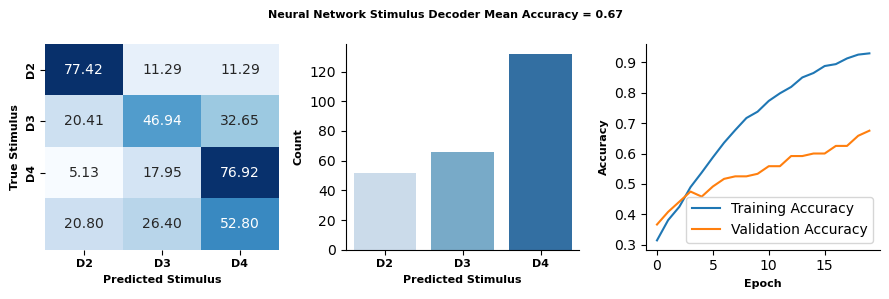

In [10]:

print(np.size(np.where(y_predfunnall==0)[0]))
print(np.size(np.where(y_predfunnall==1)[0]))
print(np.size(np.where(y_predfunnall==2)[0]))

fig, axs = plt.subplots(1, 3, figsize=(9,3), dpi=100)
ax=axs[0]
sns.heatmap(CM_all / CM_all.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.2f', cmap='Blues',ax=ax, cbar=False)
ax.set_xlabel('Predicted Stimulus',fontsize=8,fontweight='bold')
ax.set_ylabel('True Stimulus',fontsize=8,fontweight='bold')
ax.set_xticks([0.5,1.5,2.5])
ax.set_yticks([0.5,1.5,2.5])
ax.set_xticklabels(['D2','D3','D4'],fontsize=8,fontweight='bold')
ax.set_yticklabels(['D2','D3','D4'],fontsize=8,fontweight='bold')
fig.suptitle('Neural Network Stimulus Decoder Mean Accuracy = ' + str(np.round(np.mean(AccScore_MLP_allsplit),2)), fontsize=8,fontweight='bold')

ax=axs[1]
sns.barplot(x=['D2','D3','D4'], y=[np.size(np.where(y_predfunnall==0)[0]),np.size(np.where(y_predfunnall==1)[0]),np.size(np.where(y_predfunnall==2)[0])], palette='Blues', ax=ax)
ax.set_ylabel('Count',fontsize=8,fontweight='bold')
ax.set_xlabel('Predicted Stimulus',fontsize=8,fontweight='bold')
ax.set_xticks([0,1,2])
ax.set_xticklabels(['D2','D3','D4'],fontsize=8,fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax=axs[2]

ax.plot(np.mean(acchist,axis=0), label='Training Accuracy')
ax.plot(np.mean(valacchist,axis=0), label='Validation Accuracy')
ax.set_xlabel('Epoch',fontsize=8,fontweight='bold')
ax.set_ylabel('Accuracy',fontsize=8,fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()